In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

### The Bias-Variance Tradeoff
$$
\text{Expected Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}
$$

**Bias²:** How far off is your model's average prediction from the true value? (underfitting)

**Variance:** How much does your model's prediction fluctuate if you train it on a different random subset of the training data?(overfitting)

**Irreducible Error:** Noise inherent in the data (measurement errors, unobserved features). You can never reduce this.

Tradeoff: Since both Bias² and Variance are non-negative, **reducing one always increases the other** when model complexity changes.

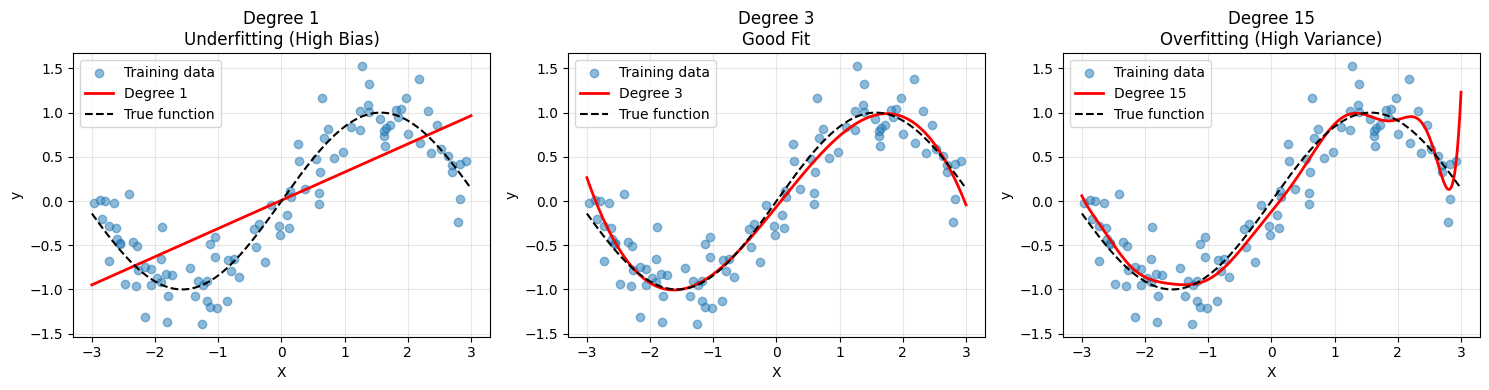

In [9]:
# Generate data with noise
np.random.seed(42)
n = 100
X = np.random.uniform(-3, 3, n).reshape(-1, 1)
y_true = np.sin(X).ravel()  # True relationship
y = y_true + np.random.normal(0, 0.3, n)  # Add noise

# Test on high-density grid
X_test = np.linspace(-3, 3, 300).reshape(-1, 1)

# Train models with different complexity
degrees = [1, 3, 15]
plt.figure(figsize=(15, 4))

for i, degree in enumerate(degrees):
    plt.subplot(1, 3, i+1)
    
    # Fit polynomial
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X, y)
    y_pred = model.predict(X_test)
    
    # Plot
    plt.scatter(X, y, alpha=0.5, label='Training data')
    plt.plot(X_test, y_pred, 'r-', linewidth=2, label=f'Degree {degree}')
    plt.plot(X_test, np.sin(X_test).ravel(), 'k--', label='True function')
    plt.title(f'Degree {degree}\n' + 
              ('Underfitting (High Bias)' if degree == 1 else 
               'Good Fit' if degree == 3 else 
               'Overfitting (High Variance)'))
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Breaking the Bias-Variance Tradeoff

You said: *"Reducing bias increases variance, and vice versa."*

**This is only true when you hold the dataset size constant.**

If you can increase your training data size, you can **break the tradeoff!**

With infinite data, you could use an extremely complex (low-bias) model and average out the variance to zero.

| Dataset Size | Model Complexity | Bias | Variance | Total Error |
|--------------|------------------|------|----------|-------------|
| Small | Simple | High | Low | High |
| Small | Complex | Low | High | High |
| **Large** | **Complex** | **Low** | **Low** | **Low** ✅ |

With enough data, you can have **both** low bias and low variance!

---

### The Bias-Variance Tradeoff: Email Assistant Analogy

You hire an assistant to summarize your daily emails so you can quickly scan them.

**High Bias (Underfitting):** Your assistant is lazy and rigid. Every day, no matter what's in your inbox, they summarize it as: "Work stuff and personal stuff."

*Result:* Never wrong in a catastrophic way, but totally useless. Misses every important detail. (Low variance, high bias).

**High Variance (Overfitting):** Your assistant is a perfectionist who reads every email 10 times, tracks the sender's mood based on punctuation, and writes a 3-page summary that perfectly captures every nuance of today's specific emails.

*Result:* Today's summary is brilliant. But tomorrow, if your boss uses a period instead of an exclamation point, the assistant panics, rewrites the entire system, and gives you a completely unhinged summary. (Low bias on today's data, but wildly inconsistent day-to-day).

**The Tradeoff:** You force them to use a strict 3-bullet-point template (increasing bias). They become less insightful, but you can finally trust them to be consistently okay.

---

### The 4 Quadrants of Model Performance

| Scenario | Bias | Variance | Problem | Diagnostic |
|----------|------|----------|---------|------------|
| **High Bias** | High | Low | Underfitting | Training error is high. Validation error is similarly high. |
| **High Variance** | Low | High | Overfitting | Training error is near 0. Validation error is much higher. |
| **High Both** | High | High | Poor data + poor model | Both errors are high and unstable. (Rare, but happens with tiny, messy datasets). |
| **Sweet Spot** | Low-ish | Low-ish | Good generalization | Training and validation errors converge to a reasonable floor. |

In [11]:
def diagnose_model(X_train, X_val, y_train, y_val, model, model_name="Model"):
    """
    Diagnose if a model is suffering from bias or variance.
    """
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    
    train_error = mean_squared_error(y_train, train_pred)
    val_error = mean_squared_error(y_val, val_pred)
    
    print(f"{model_name} Performance:")
    print(f"  Train Error: {train_error:.4f}")
    print(f"  Validation Error: {val_error:.4f}")
    print(f"  Gap: {val_error - train_error:.4f}")
    
    # Diagnosis
    if val_error > train_error * 1.2:  # Validation much worse
        print("  🔴 DIAGNOSIS: High Variance (Overfitting)")
        print("     Solution: Reduce complexity, add regularization, more data")
    elif train_error > val_error * 1.2:  # Training worse
        print("  🔴 DIAGNOSIS: High Bias (Underfitting)")
        print("     Solution: Increase complexity, add features, train longer")
    else:
        print("  ✅ DIAGNOSIS: Good balance (Low Bias & Low Variance)")
    
    return train_error, val_error

# Example with synthetic data
X = np.random.randn(500, 10)
y = 2*X[:, 0] + 0.5*X[:, 1] + np.random.randn(500) * 0.5

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3)

# Simple model (High Bias)
simple_model = LinearRegression()
diagnose_model(X_train, X_val, y_train, y_val, simple_model, "Linear Regression")

# Complex model (High Variance)
complex_model = RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_split=2)
diagnose_model(X_train, X_val, y_train, y_val, complex_model, "Deep Random Forest")

# Regularized model (Good balance)
regularized_model = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_split=10)
diagnose_model(X_train, X_val, y_train, y_val, regularized_model, "Regularized Forest")

Linear Regression Performance:
  Train Error: 0.2231
  Validation Error: 0.3045
  Gap: 0.0814
  🔴 DIAGNOSIS: High Variance (Overfitting)
     Solution: Reduce complexity, add regularization, more data
Deep Random Forest Performance:
  Train Error: 0.0487
  Validation Error: 0.4540
  Gap: 0.4054
  🔴 DIAGNOSIS: High Variance (Overfitting)
     Solution: Reduce complexity, add regularization, more data
Regularized Forest Performance:
  Train Error: 0.1706
  Validation Error: 0.4912
  Gap: 0.3206
  🔴 DIAGNOSIS: High Variance (Overfitting)
     Solution: Reduce complexity, add regularization, more data


(0.1705774117200316, 0.4911887551761838)

---

### Practical Strategies to Navigate the Tradeoff

Instead of blindly choosing model complexity, use these levers:

| Lever | What it does | Bias-Variance Effect |
|-------|--------------|----------------------|
| **Regularization (L1/L2)** | Penalizes large coefficients. | Increases bias slightly, massively decreases variance. (Your best friend for overfitting). |
| **Ensemble Methods (Bagging/RF)** | Trains multiple models and averages them. | Reduces variance without increasing bias (because the average of high-variance models has lower variance). |
| **Ensemble Methods (Boosting)** | Sequentially corrects errors. | Reduces bias without significantly increasing variance (when done with shallow trees). |
| **Early Stopping** | Halts training before convergence. | Creates a "sweet spot" where you stop increasing variance while bias is still decreasing. |
| **Feature Selection** | Removes irrelevant features. | Reduces variance (less noise to fit), may slightly increase bias if you remove a weak but real signal. |

### Regularization: Primary Tool for Controlling the Bias-Variance Tradeoff

Regularization is the primary tool for controlling the bias-variance tradeoff.

| Technique | How It Helps | What It Does |
|-----------|--------------|--------------|
| **L2 Regularization** | Reduces variance | Shrinks weights toward 0 |
| **L1 Regularization** | Reduces variance + feature selection | Shrinks some weights to 0 |
| **Dropout** | Reduces variance | Randomly drops neurons during training |
| **Early Stopping** | Reduces variance | Stops training before overfitting |
| **Data Augmentation** | Reduces variance | Creates more training data |
| **Cross-Validation** | Detects variance | Ensures model generalizes |

### The Bias-Variance Diagnostic Flowchart

Ask yourself two questions:

---

**Question A: "Is my Training Error high?"** (e.g., 40% error, or MAE of $500 when you expected $100)

- ✅ If **YES** → You have **High Bias**. Your model is too dumb. Go to **Fix #1**.
- ❌ If **NO** → Your training error is low. Good. Move to **Question B**.

---

**Question B: "Is my Validation Error significantly HIGHER than my Training Error?"** (e.g., Training error = 2%, Validation error = 25%)

- ✅ If **YES** → You have **High Variance**. Your model memorized the training set. Go to **Fix #2**.
- ❌ If **NO** → **Congratulations!** Both errors are low and close. You've found the **sweet spot**! 🎉


| What You See | What It Means | What To Do |
|--------------|---------------|------------|
| **Training Error = 40%, Validation Error = 42%** | High Bias | Increase model complexity (more features, deeper tree, polynomial terms) |
| **Training Error = 2%, Validation Error = 40%** | High Variance | Decrease complexity (prune tree, add regularization, get MORE data) |
| **Training Error = 20%, Validation Error = 25%** | Sweet Spot | You're done! Tune hyperparameters slightly. |
| **Training Error = 50%, Validation Error = 55%** | High Bias + Data Issue | You might need better features, not just a bigger model. |

**Training Error** = The error between your y_train (actual) and your y_pred (the predictions on that same training data).

**Validation/Test Error** = The error between your y_test (actual) and your y_pred (predictions on that new data)